# The `leakcheck` package

Screen a reported F1 for the signature of resampling **before** the train/test split.
The shipped model is plain JSON, evaluated by a pure-NumPy tree walker (runtime
dependency: NumPy only).

| What this notebook shows | Source |
|---|---|
| Leave-one-dataset-out ROC and the screening curves | `figures/fig05_diagnostic.png` |
| Model card (AUC, corpus, fitted ranges) | `leakcheck.model_info()` |
| Worked example on IBM HR (F1 = 0.92) | `leakcheck.check(...)` |
| Heatmap: same F1, different imbalance | live grid |
| Seven published attrition results | `literature.py` |

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

CODE = Path.cwd()
while CODE.name != 'Code' and CODE.parent != CODE:
    CODE = CODE.parent
sys.path.insert(0, str(CODE))

import numpy as np, pandas as pd
import leakage_lib as L
pd.set_option('display.width', 200, 'display.max_columns', 60)
print('corpus  :', L.PROC)
print('results :', L.RES)

import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10, 'figure.facecolor': 'white'})
BLUE, RED, GREY, GREEN = L.BLUE, L.RED, L.GREY, L.GREEN

PKG = L.ROOT
sys.path.insert(0, str(PKG/'src'))
print('package :', PKG)
print('figure  :', L.FIG/'fig05_diagnostic.png')

## 1. The screen, as published

Panel (a) is leave-one-dataset-out detection on the 41-dataset corpus.
Panel (b) is what a reviewer sees: P(leaked) as a function of the reported F1,
at four imbalance ratios.

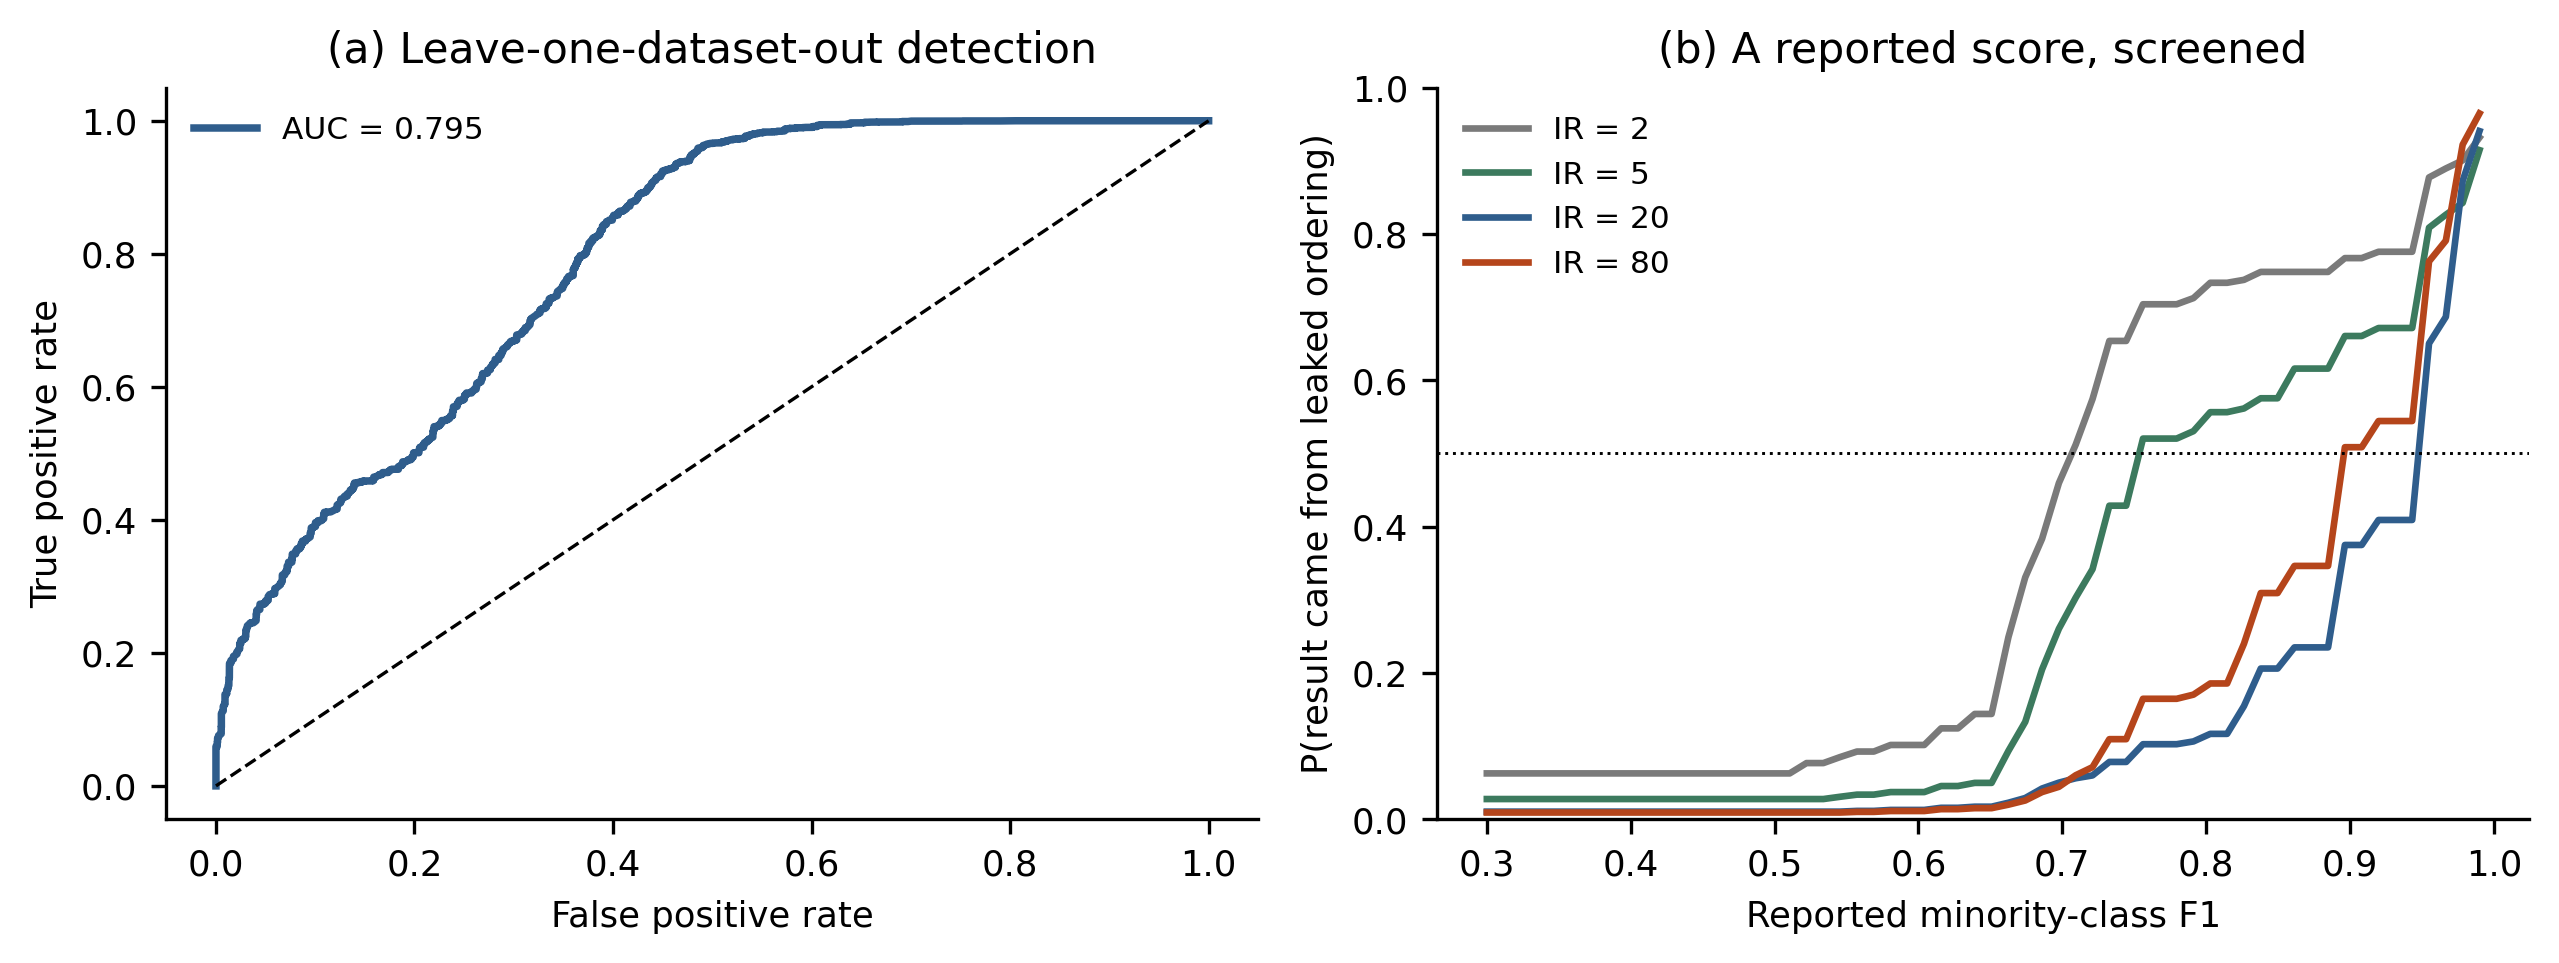

,Diagnostic,Value
0,Leave-one-dataset-out AUC,0.795
1,Accuracy at 0.5,0.697
2,Brier score,0.197
3,Datasets scored,41
4,Datasets with AUC > 0.9,27
5,Paired examples,22400


In [2]:
fig05 = L.FIG / 'fig05_diagnostic.png'
if fig05.exists():
    display(Image(str(fig05), width=860))
else:
    print('fig05_diagnostic.png missing — run Code/03_analysis.py first')

S = json.load(open(L.RES/'summary.json'))
pd.DataFrame([
    ('Leave-one-dataset-out AUC', f"{S['diag_auc']:.3f}"),
    ('Accuracy at 0.5', f"{S['diag_acc']:.3f}"),
    ('Brier score', f"{S['diag_brier']:.3f}"),
    ('Datasets scored', S['diag_n_datasets_scored']),
    ('Datasets with AUC > 0.9', S['diag_n_datasets_above_09']),
    ('Paired examples', S['diag_n']),
], columns=['Diagnostic', 'Value'])

## 2. The shipped model

In [3]:
# Re-export only if the JSON is missing.
model_json = PKG/'src'/'leakcheck'/'model.json'
if not model_json.exists():
    !python "04_export_model.py"
else:
    print('using existing', model_json)

import importlib, leakcheck
importlib.reload(leakcheck)
info = leakcheck.model_info()
card = pd.DataFrame([
    ('Trees', info['n_trees']),
    ('LODO AUC', f"{info['lodo_auc']:.3f}"),
    ('Datasets', info['n_datasets']),
    ('Training examples', info['n_examples']),
    ('Imbalance range', f"{info['ir_range'][0]:.2f} – {info['ir_range'][1]:.1f}"),
    ('Minority-count range', f"{info['nmin_range'][0]} – {info['nmin_range'][1]}"),
    ('Classifier families', ', '.join(info['classifiers'])),
], columns=['Model card', 'Value'])
display(card)
assert leakcheck.selftest(), 'shipped fixtures drifted'
print('selftest: shipped JSON matches stored fixtures')

## 3. Worked example — IBM HR, reported F1 = 0.92

A headline score that is common in the attrition literature, on a problem with
237 leavers and imbalance 5.2 : 1.

Reported minority-class F1 of 0.920 on a problem with imbalance ratio 5.2, 237 minority cases and 44 features, using RandomForest (screened as the RandForest family). Estimated probability that this result was produced by resampling before the train/test split: 0.83 -- likely leaked. On this corpus, correctly evaluated results at that difficulty average about F1 0.68. This is a screen, not a finding. The appropriate response is to ask where the resampler sits relative to the split.


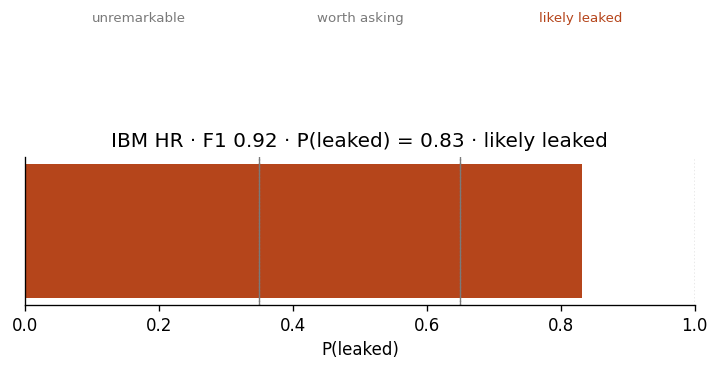

In [4]:
r = leakcheck.check(f1=0.92, imbalance_ratio=5.2, n_minority=237,
                    n_features=44, clf='RandomForest')
print(r.explain())

cuts = list(leakcheck.THRESHOLDS.items())
fig, ax = plt.subplots(figsize=(7.2, 1.6))
ax.barh([0], [r.probability], color=RED, height=0.45)
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel('P(leaked)')
for label, cut in cuts:
    ax.axvline(cut if cut <= 1 else 1, color=GREY, lw=0.8, ls=':')
ax.axvline(0.35, color=GREY, lw=0.8)
ax.axvline(0.65, color=GREY, lw=0.8)
ax.text(0.17, 0.7, 'unremarkable', ha='center', color=GREY, fontsize=8)
ax.text(0.50, 0.7, 'worth asking', ha='center', color=GREY, fontsize=8)
ax.text(0.83, 0.7, 'likely leaked', ha='center', color=RED, fontsize=8)
ax.set_title(f'IBM HR · F1 0.92 · P(leaked) = {r.probability:.2f} · {r.verdict}')
fig.tight_layout()
plt.show()

## 4. The same F1 is ordinary on an easy problem and alarming on a hard one

,f1,imbalance_ratio,n_minority,n_features,clf,family,probability,verdict,expected_honest_f1
0,0.45,2.0,200,30,RandomForest,RandForest,0.065,unremarkable,0.735
1,0.45,10.0,200,30,RandomForest,RandForest,0.011,unremarkable,0.650
2,0.45,50.0,200,30,RandomForest,RandForest,0.009,unremarkable,0.564
3,0.70,2.0,200,30,RandomForest,RandForest,0.475,worth asking about,0.735
4,0.70,10.0,200,30,RandomForest,RandForest,0.053,unremarkable,0.650
5,0.70,50.0,200,30,RandomForest,RandForest,0.057,unremarkable,0.564
6,0.92,2.0,200,30,RandomForest,RandForest,0.745,likely leaked,0.735
7,0.92,10.0,200,30,RandomForest,RandForest,0.369,worth asking about,0.650
8,0.92,50.0,200,30,RandomForest,RandForest,0.502,worth asking about,0.564


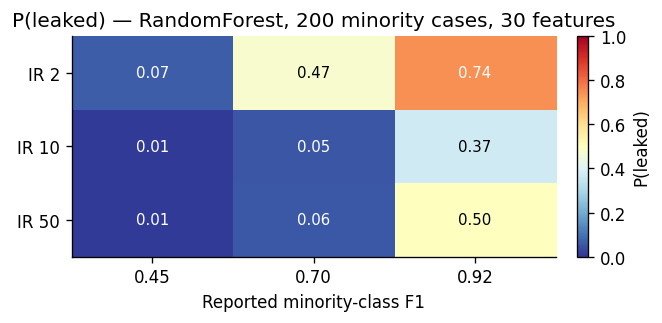

In [5]:
rows = [dict(f1=f, imbalance_ratio=ir, n_minority=200, n_features=30, clf='RandomForest')
        for f in (0.45, 0.70, 0.92) for ir in (2, 10, 50)]
grid = leakcheck.check_many(rows).round(3)
display(grid)

piv = grid.pivot(index='imbalance_ratio', columns='f1', values='probability')
fig, ax = plt.subplots(figsize=(5.6, 2.8))
im = ax.imshow(piv.to_numpy(), cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(piv.columns)), [f'{c:.2f}' for c in piv.columns])
ax.set_yticks(range(len(piv.index)), [f'IR {int(i)}' for i in piv.index])
ax.set_xlabel('Reported minority-class F1')
ax.set_title('P(leaked) — RandomForest, 200 minority cases, 30 features')
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.to_numpy()[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v > 0.55 or v < 0.15 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='P(leaked)')
fig.tight_layout()
plt.show()

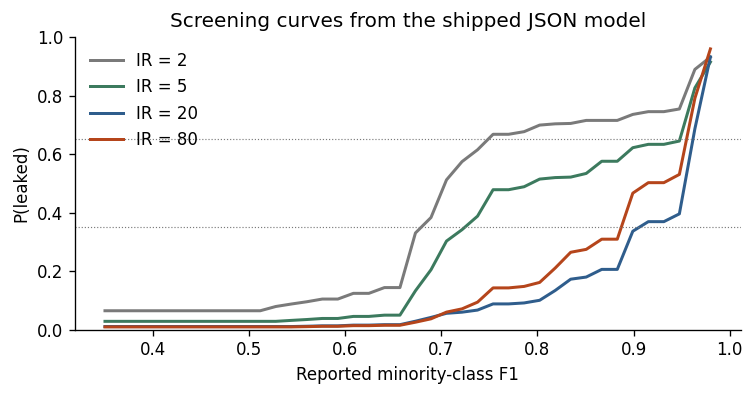

In [6]:
f1s = np.linspace(0.35, 0.98, 40)
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for ir, c in zip([2, 5, 20, 80], [GREY, GREEN, BLUE, RED]):
    ps = [leakcheck.check(f1=f, imbalance_ratio=ir, n_minority=200,
                          n_features=30, clf='RandomForest').probability
          for f in f1s]
    ax.plot(f1s, ps, color=c, lw=1.8, label=f'IR = {ir}')
ax.axhline(0.35, color=GREY, lw=0.7, ls=':')
ax.axhline(0.65, color=GREY, lw=0.7, ls=':')
ax.set(xlabel='Reported minority-class F1', ylabel='P(leaked)',
       ylim=(0, 1), title='Screening curves from the shipped JSON model')
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
plt.show()

## 5. Screen the published attrition literature

,study,dataset,model,f1,protocol,P(leaked)
0,Hamja et al. (2025),IBM HR,GradientBoosting,0.990,not stated,0.963
1,Nassreddine et al. (2026),IBM HR,Ensemble (ROS),0.977,not stated,0.928
2,Baydili & Tasci (2025),IBM HR,GAN-Transformer,0.916,before-split,0.893
3,AL-Ali et al. (2026),IBM HR,AdaBoost,0.797,not stated,0.785
5,Alyousef et al. (2026),IBM HR,LogisticRegression,0.504,train-only,0.064
6,Cavescu & Popescu (2026),IBM HR,LogisticRegression,0.439,train-only,0.064
4,AL-Ali et al. (2026),Job change,HistGradientBoosting,0.659,not stated,0.008


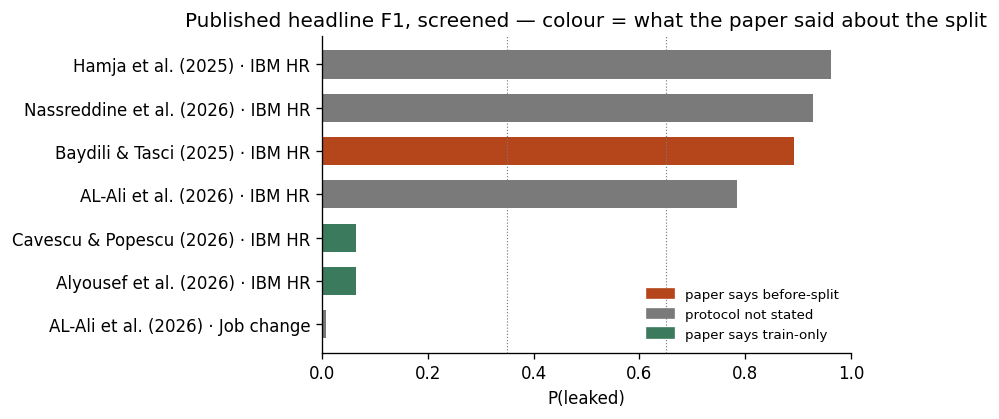

In [7]:
import literature
lit = literature.screened().copy()
show = lit[['study', 'dataset', 'model', 'f1', 'protocol', 'p_leaked']].round(3)
show = show.rename(columns={'p_leaked': 'P(leaked)'})
display(show.sort_values('P(leaked)', ascending=False))

fig, ax = plt.subplots(figsize=(7.4, 3.6))
d = lit.sort_values('p_leaked')
col = d.protocol.map({'before-split': RED, 'train-only': GREEN, 'not stated': GREY})
ax.barh(range(len(d)), d.p_leaked, color=col, height=0.65)
ax.set_yticks(range(len(d)), [f"{s} · {ds}" for s, ds in zip(d.study, d.dataset)])
ax.set_xlabel('P(leaked)')
ax.set_xlim(0, 1)
ax.axvline(0.35, color=GREY, lw=0.7, ls=':')
ax.axvline(0.65, color=GREY, lw=0.7, ls=':')
ax.set_title('Published headline F1, screened — colour = what the paper said about the split')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=RED, label='paper says before-split'),
    Patch(color=GREY, label='protocol not stated'),
    Patch(color=GREEN, label='paper says train-only'),
], frameon=False, loc='lower right', fontsize=8)
fig.tight_layout()
plt.show()

## 6. Tests, then build the paper

In [8]:
!cd .. && python -m pytest -q

In [9]:
print('Run tests from the repository root: python -m pytest -q')